Customer Churn Prediction

Is project mein hum predict karenge ki koi customer telecom company chhodega (churn) ya nahi, uski details dekh kar - jaise contract type, monthly charges, aur kitne mahine se customer hai.

Dataset : Telco Customer Churn (IBM Sample Dataset) - 7,043 customers, 21 columns

In [24]:
# Imports

import pandas as pd                                # Data table hadle karne ke liye 
import numpy as np                                 # MAth calculation ke liye 
import matplotlib.pyplot as plt                    # Graph  banane ke liye 

from sklearn.model_selection import train_test_split                                       # Data ko train/testmein baatne ke liye 
from sklearn.linear_model import LogisticRegression                                        # Classification model 
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix   #Accuracy check karne ke liye 

In [25]:
# Data Load

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")    #Cd file load kr rahe hai 

In [26]:
df.shape      #Number of row and column batata hai 

(7043, 21)

In [27]:
# Data info and missing values check 

df.info()    # Har column ka nonull count and dtypes and  memory_usage batata hai 

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [28]:
df.isnull().sum()  # Har column mai kitni missing values and kitni  null values hai batata hai 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [29]:
# Target column dekho(kitne customer aye hai ya nahi aye hai)

print(df['Churn'].value_counts())   # Kitne customers stay kiye(no) or kitne chale gaye (yes) 

Churn
No     5174
Yes    1869
Name: count, dtype: int64


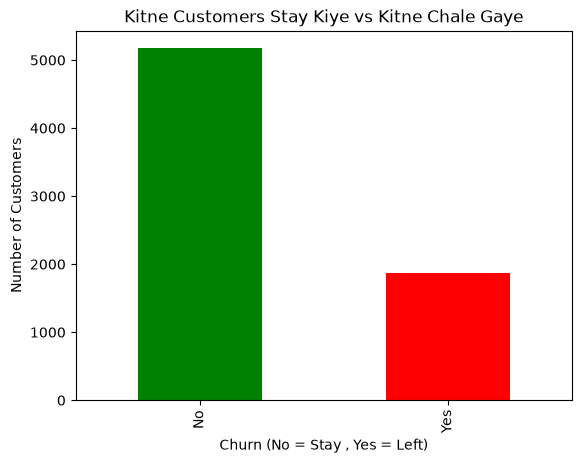

In [30]:
# 1. Churn ka data count karke Green aur Red rang ka Bar Chart banana
df['Churn'].value_counts().plot(kind = 'bar', color = ['green','red'])    

# 2. Graph me Title aur Labels (X aur Y axis) set karna
plt.title('Kitne Customers Stay Kiye vs Kitne Chale Gaye') 
plt.xlabel('Churn (No = Stay , Yes = Left)') 
plt.ylabel('Number of Customers') 

# 3. Graph ko screen par show karna
plt.show()

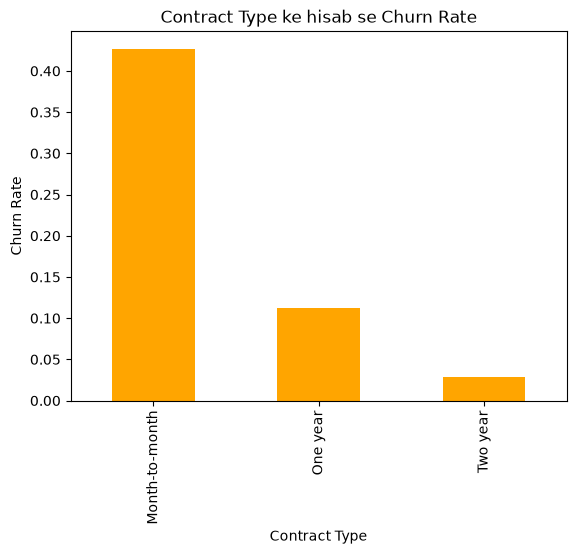

In [31]:
# Graph 2: Contract type ke hisab se churn rate average churn rate  dekha - business insight ke liye 

df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean()).plot(kind = 'bar',color = 'orange')

plt.title('Contract Type ke hisab se Churn Rate')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.show()

In [32]:
#7 TotalCharges column text (string)hai,use number banana zaroori hai 
df['TotalCharges'] = pd.to_numeric(df["TotalCharges"], errors = 'coerce')    # error = 'coerce' ka matlab: jo value number nahi ban payi ,use NaN (Khali) bana do 

print(df['TotalCharges'].isnull().sum())  # kitni rows khali ban gayi,check kiya hai 

11


In [33]:
df = df.dropna()  # jo  bhi rows kahli hai unhe  drop kr dega hata dega 
df.shape          # hatane ke baad check kiya hai humne

(7032, 21)

In [34]:
# Unnecessary column drop karo 

df = df.drop('customerID', axis = 1)  #ye customeID jai isse predictin mai koi bhi help nahimelti unnecessary hai isliye ise delete kiya hu 
df.head()                             # Check kiya data kaisa dikh raha hai 

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
# Target column ko number banao 

#Churn column ,mein 'Yes/'No' text hai, mein badal diya
df['Churn'] = df['Churn'].map({'Yes': 1 , 'No' : 0})
df['Churn'].head()    #Check kiya sahi convert hua

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [36]:
# Baaki categorical columns ko number mein badlo 

# Jo column text (Yes/No, Male/Female waghera) hain, unhe one - hot encoding se number banaya 

df = pd.get_dummies(df, drop_first = True)
df.shape      #Encoding le baad kitne ban gaye, check kiya 

(7032, 31)

In [37]:
# Train - test split 

x = df.drop('Churn',axis = 1)    # Churn ke alawa sab features (input) hai 
y = df['Churn']                  # Churn = target (jo predict karna hai)

# Data ko 80% training aur 20% testiung mein baant diya 
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.20 , random_state= 42)

print('Training :', X_train.shape)
print('Testing:',X_test.shape)

Training : (5625, 30)
Testing: (1407, 30)


In [ ]:
#12 Model Train Karo 

model = LogisticRegression(max_iter=2000)   # Model banaya (max_iter badhaya taaki achhe se converge ho)
model.fit(X_train, y_train)                 # Training data se model ne seekha

y_train_pred = model.predict(X_train)   # Training data pe prediction
y_test_pred = model.predict(X_test)     # Testing data pe prediction (jo model ne kabhi nahi dekha)

c:\Users\Hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
# Metrics (train vs test compare,overfitting check)

train_acc = accuracy_score(y_train,y_train_pred)
train_prec = precision_score(y_train,y_train_pred)
train_rec = recall_score(y_train,y_train_pred)


test_acc = accuracy_score(y_test,y_test_pred)
test_prec = precision_score(y_test,y_test_pred)
test_rec = recall_score(y_test,y_test_pred)

print('Training Accuracy :',round(train_acc*100,2),'%')
print('Training Accuracy :',round(train_prec*100,2),'%')
print('Training Accuracy :',round(train_rec*100,2),'%')
print()

print('Training Accuracy :',round(test_acc*100,2),'%')
print('Training Accuracy :',round(test_prec*100,2),'%')
print('Training Accuracy :',round(test_rec*100,2),'%')


Training Accuracy : 80.85 %
Training Accuracy : 66.35 %
Training Accuracy : 56.72 %

Training Accuracy : 78.82 %
Training Accuracy : 62.26 %
Training Accuracy : 51.6 %


In [45]:
# confusion Matrix 

cm = confusion_matrix(y_test, y_test_pred)   # Confusion matrix banaya
TN, FP, FN, TP = cm.ravel()   # 4 values nikali: sahi/galat predictions

print("Confusion Matrix:")
print(cm)
print("True Negative (sahi bola nahi chhodega):", TN)
print("False Positive (galat bola chhodega):", FP)
print("False Negative (galat bola nahi chhodega):", FN)
print("True Positive (sahi bola chhodega):", TP)




Confusion Matrix:
[[916 117]
 [181 193]]
True Negative (sahi bola nahi chhodega): 916
False Positive (galat bola chhodega): 117
False Negative (galat bola nahi chhodega): 181
True Positive (sahi bola chhodega): 193
